In [41]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar



In [42]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_harlequin_V3.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_006_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [43]:
def run_decay_case(model_path, A0, exp_time, exp_signal, delta_t_exp,
                   linear_damping, quadratic_damping):
    """
    Draait 1 OrcaFlex decay case en vergelijkt met experiment.
    """

    # -------------------------
    # model opnieuw openen
    # -------------------------
    model = OrcFxAPI.Model(model_path)
    constraint = model["decay_constraint"]
    floaters = model["floaters"]
    floatertype = model["Floatertype"]

    # -------------------------
    # beginverplaatsing zetten
    # -------------------------


    # -------------------------
    constraint.InFrameInitialZ = A0
    constraint.InFrameInitialX = 0
    constraint.InFrameInitialY = 0
    constraint.InFrameInitialAzimuth = 0
    constraint.InFrameInitialDeclination = 0 
    constraint.InFrameInitialGamma = 0

    floatertype.OtherDampingLinearCoeffx = 0 #surge
    floatertype.OtherDampingLinearCoeffy = 0 #sway
    floatertype.OtherDampingLinearCoeffz  = linear_damping
    floatertype.OtherDampingLinearCoeffRx = 0 #roll
    floatertype.OtherDampingLinearCoeffRy = 0 #pitch
    floatertype.OtherDampingLinearCoeffRz = 0 #yaw

    floatertype.OtherDampingQuadraticCoeffx = 0 #surge
    floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
    floatertype.OtherDampingQuadraticCoeffz = quadratic_damping #heav
    floatertype.OtherDampingQuadraticCoeffRx = 0#roll
    floatertype.OtherDampingQuadraticCoeffRy = 0 #pitch
    floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw
        # run
    # -------------------------
    model.RunSimulation()

    
    t_sim = model.general.TimeHistory("Time")
    z_sim = floaters.TimeHistory("Z")

    t_exp0 = exp_time - exp_time[0]
    t_sim0 = t_sim - t_sim[0]

    f_sim = interp1d(
        t_sim0,
        z_sim,
        bounds_error=False,
        fill_value=np.nan
    )

    def compute_rmse(shift):
        z_sim_trial = f_sim(t_exp0 - shift)
        mask = ~np.isnan(z_sim_trial)

        if np.sum(mask) < 10:
            return 1e9

        z_exp_use = exp_signal[mask]
        z_sim_use = z_sim_trial[mask]

        z_offset = np.mean(z_exp_use - z_sim_use)
        error = (z_sim_use + z_offset) - z_exp_use

        return np.sqrt(np.mean(error**2))

    result = minimize_scalar(
        compute_rmse,
        bounds=(-2.0, 2.0),
        method="bounded"
    )

    best_shift = result.x
    z_sim_fit = f_sim(t_exp0 - best_shift)
    mask = ~np.isnan(z_sim_fit)

    z_exp_plot = exp_signal[mask]
    z_sim_plot_raw = z_sim_fit[mask]

    best_z_offset = np.mean(z_exp_plot - z_sim_plot_raw)
    z_sim_plot = z_sim_plot_raw + best_z_offset

    error = z_sim_plot - z_exp_plot
    rmse = np.sqrt(np.mean(error**2))
    mae = np.mean(np.abs(error))

    t_plot = t_exp0[mask]
    z_exp_plot = exp_signal[mask] - exp_signal[mask][0]
    z_sim_plot = z_sim_fit[mask] - z_sim_fit[mask][0]

    error = z_sim_plot - z_exp_plot
    rmse = np.sqrt(np.mean(error**2))
    mae = np.mean(np.abs(error))

    return {
        "linear_damping": linear_damping,
        "quadratic_damping": quadratic_damping,
        "best_time_shift": best_shift,
        "best_z_offset": best_z_offset,
        "rmse": rmse,
        "mae": mae,
        "t_plot": t_plot,
        "z_exp_plot": z_exp_plot,
        "z_sim_plot": z_sim_plot,
    }

In [44]:
with h5py.File(exp_path, "r") as f:
    t_exp = f["CroppedSignals/time"][:]
    z_exp = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unfiltered,
    "z_unfiltered [m]": z_unfiltered
})


In [45]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

delta_t_exp = t_decay_start - t_init
t_exp_decay = t_exp - t_decay_start

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

Decay start time           = 1087.008 s
Quiet window               = [1025.008, 1075.008] s
Equilibrium level z_eq     = 0.021210 m
Search window              = [1082.008, 1087.008] s
Initial extreme at t       = 1082.033 s
Initial extreme z          = -3.157819 m
Initial amplitude A0       = 3.179029 m
Signed amplitude           = -3.179029 m


In [46]:
target_rmse = 0.20
target_mae = 0.15

c_lin = 1
c_quad =1

step_lin = 0.2
step_quad = 0.2

min_step_lin = 0.05
min_step_quad = 0.05

max_iter = 40

max_lin = 20.0
max_quad = 20.0

result = run_decay_case(
    model_path=model_path,
    A0=A0,
    exp_time=t_exp_decay,
    exp_signal=z_exp,
    delta_t_exp=delta_t_exp,
    linear_damping=c_lin,
    quadratic_damping=c_quad
)

print("RMSE =", result["rmse"])
print("MAE  =", result["mae"])



RMSE = 2.823302042308241
MAE  = 2.5217076124620688


In [47]:
def evaluate_case(c_lin, c_quad):
    result = run_decay_case(
        model_path=model_path,
        A0=A0,
        exp_time=t_exp_decay,
        exp_signal=z_exp,
        delta_t_exp=delta_t_exp,
        linear_damping=c_lin,
        quadratic_damping=c_quad
    )
    return result

In [48]:
def objective(c_lin, c_quad):
    res = evaluate_case(c_lin, c_quad)
    return res["rmse"], res


def optimize_one_parameter(current_lin, current_quad, step, parameter="lin",
                           growth_factor=1.2, shrink_factor=0.5,
                           min_step=0.05, max_trials=10,
                           max_lin=100.0, max_quad=100.0):
    """
    Optimaliseer 1 parameter (lin of quad) met de andere vast.
    Probeert eerst +step en -step.
    Als verbetering gevonden wordt, blijft hij die richting op gaan.
    Met onder- en bovengrens op damping.
    """

    # huidige waarden ook meteen begrenzen
    current_lin = np.clip(current_lin, 0.0, max_lin)
    current_quad = np.clip(current_quad, 0.0, max_quad)

    current_rmse, current_res = objective(current_lin, current_quad)

    best_lin = current_lin
    best_quad = current_quad
    best_rmse = current_rmse
    best_res = current_res

    if parameter == "lin":
        candidates = [
            (np.clip(current_lin + step, 0.0, max_lin), current_quad),
            (np.clip(current_lin - step, 0.0, max_lin), current_quad),
        ]
    else:
        candidates = [
            (current_lin, np.clip(current_quad + step, 0.0, max_quad)),
            (current_lin, np.clip(current_quad - step, 0.0, max_quad)),
        ]

    # dubbele kandidaten vermijden, bv. aan de rand
    candidates = list(dict.fromkeys(candidates))

    # eerst beste richting bepalen
    trial_results = []
    for lin, quad in candidates:
        rmse, res = objective(lin, quad)
        trial_results.append((lin, quad, rmse, res))

    trial_results.sort(key=lambda x: x[2])
    candidate_lin, candidate_quad, candidate_rmse, candidate_res = trial_results[0]

    # geen verbetering -> stap verkleinen
    if candidate_rmse >= best_rmse:
        return {
            "best_lin": best_lin,
            "best_quad": best_quad,
            "best_rmse": best_rmse,
            "best_res": best_res,
            "new_step": max(step * shrink_factor, min_step),
            "improved": False
        }

    # wel verbetering -> blijf in dezelfde richting bewegen
    direction_lin = candidate_lin - current_lin
    direction_quad = candidate_quad - current_quad

    best_lin = candidate_lin
    best_quad = candidate_quad
    best_rmse = candidate_rmse
    best_res = candidate_res

    step_local = step

    for _ in range(max_trials):
        step_local *= growth_factor

        if parameter == "lin":
            next_lin = np.clip(best_lin + np.sign(direction_lin) * step_local, 0.0, max_lin)
            next_quad = best_quad
        else:
            next_lin = best_lin
            next_quad = np.clip(best_quad + np.sign(direction_quad) * step_local, 0.0, max_quad)

        # als je tegen de grens aanzit en dus niet meer beweegt: stop
        if np.isclose(next_lin, best_lin) and np.isclose(next_quad, best_quad):
            break

        next_rmse, next_res = objective(next_lin, next_quad)

        if next_rmse < best_rmse:
            best_lin = next_lin
            best_quad = next_quad
            best_rmse = next_rmse
            best_res = next_res
        else:
            break

    return {
        "best_lin": best_lin,
        "best_quad": best_quad,
        "best_rmse": best_rmse,
        "best_res": best_res,
        "new_step": step_local,
        "improved": True
    }

In [49]:


history = []

current_rmse, current_res = objective(c_lin, c_quad)

for i in range(max_iter):
    print(f"\nIteratie {i+1}")
    print(f"Startpunt: c_lin={c_lin:.4f}, c_quad={c_quad:.4f}, RMSE={current_rmse:.6f}")

    old_rmse = current_rmse

    # 1. optimaliseer lineaire damping
    result_lin = optimize_one_parameter(
        current_lin=c_lin,
        current_quad=c_quad,
        step=step_lin,
        parameter="lin",
        min_step=min_step_lin,
        max_lin=max_lin,
        max_quad=max_quad
    )

    c_lin = result_lin["best_lin"]
    c_quad = result_lin["best_quad"]
    current_rmse = result_lin["best_rmse"]
    current_res = result_lin["best_res"]
    step_lin = result_lin["new_step"]

    print(f"Na lin-opt: c_lin={c_lin:.4f}, c_quad={c_quad:.4f}, RMSE={current_rmse:.6f}, step_lin={step_lin:.4f}")

    # 2. optimaliseer quadratische damping
    result_quad = optimize_one_parameter(
        current_lin=c_lin,
        current_quad=c_quad,
        step=step_quad,
        parameter="quad",
        min_step=min_step_quad,
        max_lin=max_lin,
        max_quad=max_quad
    )

    c_lin = result_quad["best_lin"]
    c_quad = result_quad["best_quad"]
    current_rmse = result_quad["best_rmse"]
    current_res = result_quad["best_res"]
    step_quad = result_quad["new_step"]

    print(f"Na quad-opt: c_lin={c_lin:.4f}, c_quad={c_quad:.4f}, RMSE={current_rmse:.6f}, step_quad={step_quad:.4f}")

    history.append({
        "iteration": i + 1,
        "linear_damping": c_lin,
        "quadratic_damping": c_quad,
        "rmse": current_rmse,
        "mae": current_res["mae"],
        "step_lin": step_lin,
        "step_quad": step_quad,
        "best_time_shift": current_res["best_time_shift"]
    })

    # stopcriterium
    improvement = old_rmse - current_rmse
    if improvement < tol_rmse and step_lin <= min_step_lin and step_quad <= min_step_quad:
        print("Convergentie bereikt.")
        break


Iteratie 1
Startpunt: c_lin=1.0000, c_quad=1.0000, RMSE=2.823302
Na lin-opt: c_lin=1.0000, c_quad=1.0000, RMSE=2.823302, step_lin=0.1000
Na quad-opt: c_lin=1.0000, c_quad=7.4301, RMSE=2.055469, step_quad=1.2383

Iteratie 2
Startpunt: c_lin=1.0000, c_quad=7.4301, RMSE=2.055469
Na lin-opt: c_lin=4.2150, c_quad=7.4301, RMSE=1.980495, step_lin=0.6192
Na quad-opt: c_lin=4.2150, c_quad=19.7268, RMSE=1.660280, step_quad=3.6977

Iteratie 3
Startpunt: c_lin=4.2150, c_quad=19.7268, RMSE=1.660280
Na lin-opt: c_lin=4.2150, c_quad=19.7268, RMSE=1.660280, step_lin=0.3096
Na quad-opt: c_lin=4.2150, c_quad=19.7268, RMSE=1.660280, step_quad=1.8488

Iteratie 4
Startpunt: c_lin=4.2150, c_quad=19.7268, RMSE=1.660280
Na lin-opt: c_lin=4.5246, c_quad=19.7268, RMSE=1.659914, step_lin=0.3715
Na quad-opt: c_lin=4.5246, c_quad=19.7268, RMSE=1.659914, step_quad=0.9244

Iteratie 5
Startpunt: c_lin=4.5246, c_quad=19.7268, RMSE=1.659914
Na lin-opt: c_lin=4.5246, c_quad=19.7268, RMSE=1.659914, step_lin=0.1858
Na qu

,iteration,linear_damping,quadratic_damping,rmse,mae,step_lin,step_quad,best_time_shift
0,1,1.000000,7.430084,2.055469,1.954124,0.100000,1.238347,1.523964
1,2,4.215042,19.726773,1.660280,1.582394,0.619174,3.697685,1.165405
2,3,4.215042,19.726773,1.660280,1.582394,0.309587,1.848843,1.165405
3,4,4.524629,19.726773,1.659914,1.582324,0.371504,0.924421,1.165404
4,5,4.524629,19.726773,1.659914,1.582324,0.185752,0.462211,1.165404
5,6,4.524629,19.726773,1.659914,1.582324,0.092876,0.231105,1.165404
6,7,4.617505,19.726773,1.659807,1.582303,0.111451,0.115553,1.165406
7,8,4.617505,19.726773,1.659807,1.582303,0.055726,0.057776,1.165406
8,9,4.673230,19.726773,1.659743,1.582291,0.066871,0.050000,1.165407
9,10,4.673230,19.726773,1.659743,1.582291,0.050000,0.050000,1.165407


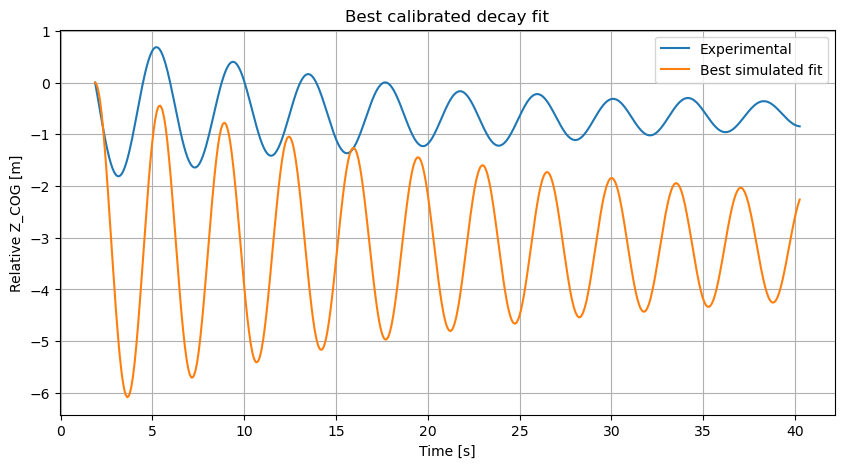

Beste gevonden waarden:
linear damping    = 4.673230
quadratic damping = 19.726773
RMSE              = 1.659743
MAE               = 1.582291


In [50]:
df_history = pd.DataFrame(history)
display(df_history)

best_result = evaluate_case(c_lin, c_quad)

plt.figure(figsize=(10, 5))
plt.plot(result["t_plot"], result["z_exp_plot"], label="Experimental")
plt.plot(result["t_plot"], result["z_sim_plot"], label="Best simulated fit")
plt.xlabel("Time [s]")
plt.ylabel("Relative Z_COG [m]")
plt.title("Best calibrated decay fit")
plt.grid(True)
plt.legend()
plt.show()

print("Beste gevonden waarden:")
print(f"linear damping    = {c_lin:.6f}")
print(f"quadratic damping = {c_quad:.6f}")
print(f"RMSE              = {best_result['rmse']:.6f}")
print(f"MAE               = {best_result['mae']:.6f}")

In [53]:
print("exp start:",result["z_exp_plot"][0])
print("exp mean last 100:", np.mean(result["z_exp_plot"][-100:]))

print("sim start:", result["z_sim_plot"][0])
print("sim mean last 100:", np.mean(result["z_sim_plot"][-100:]))
print("sim min/max:", np.min(result["z_sim_plot"]), np.max(result["z_sim_plot"]))

exp start: 0.0
exp mean last 100: -0.6582072
sim start: 0.0
sim mean last 100: -3.117994041319112
sim min/max: -6.085627529071974 0.0
